# GB Day-Ahead Price Regime Clustering

Discovers a small set of economically meaningful daily market regimes from 3 years of GB half-hourly electricity data (2023-01-01 to 2026-03-01).

**Pipeline:**
1. Load data from Elexon API + NESO CSVs
2. Build (date, SP) panel → compute net load
3. Clean days (DST + completeness)
4. Within-day z-score normalisation
5. Daily feature construction (shape vectors + summary stats)
6. RobustScaler across days
7. KMeans + GMM for k=3,4,5,6
8. Evaluate + interpret
9. Save artifacts

## 1. Setup

In [1]:
import sys
sys.path.insert(0, '.')  # ensure src/ is importable from project root

import logging
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import joblib

from src.clustering import config
from src.clustering.config import (
    START_DATE, END_DATE,
    ARTIFACTS_DIR, PROCESSED_DATA_DIR,
    CLUSTERING_DAILY_PARQUET,
    SCALER_PATH, KMEANS_PATH_TEMPLATE, GMM_PATH_TEMPLATE,
    REGIME_LABELS_PATH,
    FEATURE_COLS, SUMMARY_COLS,
)
from src.clustering.data_loader import (
    load_mip, load_demand_forecast,
    load_wind_forecast, load_embedded_forecast,
)
from src.clustering.pipeline import (
    build_half_hourly_panel, filter_eligible_days,
    normalize_shape_within_day, construct_daily_features,
    scale_features,
)
from src.clustering.models import fit_kmeans, fit_gmm
from src.clustering.evaluation import (
    evaluate_clusters, plot_cluster_profiles,
    plot_summary_distributions, plot_seasonality,
    plot_negative_and_spike_days, stability_analysis,
)

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
logger = logging.getLogger(__name__)

matplotlib.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

# Ensure output directories exist
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Data range: {START_DATE} to {END_DATE}')
print(f'Artifacts dir: {ARTIFACTS_DIR}')

Data range: 2023-01-01 to 2026-03-01
Artifacts dir: /Users/haowu/Projects/BESS/artifacts/clustering


## 2. Data Loading

### 2a. Elexon API (auto-fetched and cached)

MIP and Demand Forecast are fetched automatically from the Elexon BMRS API.

### 2b. NESO API (auto-fetched and cached)

Day-ahead wind and embedded solar/wind forecasts are fetched automatically from the NESO datastore API.
Results are cached as `.parquet` files in `data/raw/wind/` and `data/raw/embedded/`.

In [2]:
# --- Elexon API data (auto-fetched) ---
print('Loading MIP...')
mip = load_mip(START_DATE, END_DATE)
print(f'  MIP: {len(mip):,} rows, dates: {mip.settlement_date.min()} to {mip.settlement_date.max()}')


INFO: Fetching MIP from Elexon API (2023-01-01 to 2026-03-01)…


Loading MIP...


INFO: MIP cached to /Users/haowu/Projects/BESS/data/raw/mip/mip_2023-01-01_2026-03-01.parquet (55482 rows)


  MIP: 55,482 rows, dates: 2023-01-01 to 2026-03-01


In [3]:
print('Loading demand forecast...')
demand = load_demand_forecast(START_DATE, END_DATE)
print(f'  Demand: {len(demand):,} rows')


INFO: Fetching demand forecast from Elexon API (2023-01-01 to 2026-03-01)…


Loading demand forecast...


INFO: Demand cached to /Users/haowu/Projects/BESS/data/raw/demand/demand_2023-01-01_2026-03-01.parquet (55488 rows)


  Demand: 55,488 rows


In [4]:
# --- NESO API data (auto-fetched and cached) ---
print('Loading wind forecast...')
wind = load_wind_forecast(START_DATE, END_DATE)
print(f'  Wind: {len(wind):,} rows, dates: {wind.settlement_date.min()} to {wind.settlement_date.max()}')

print('Loading embedded forecast...')
embedded = load_embedded_forecast(START_DATE, END_DATE)
print(f'  Embedded: {len(embedded):,} rows')

INFO: Loading wind forecast from cache: /Users/haowu/Projects/BESS/data/raw/wind/wind_2023-01-01_2026-03-01.parquet
INFO: Loading embedded forecast from cache: /Users/haowu/Projects/BESS/data/raw/embedded/embedded_da_2023-01-01_2026-03-01.parquet


Loading wind forecast...
  Wind: 55,488 rows, dates: 2023-01-01 to 2026-03-01
Loading embedded forecast...
  Embedded: 54,960 rows


## 3. Panel Building

Align all series to a `(settlement_date, settlement_period)` MultiIndex and compute `net_load`.

In [5]:
panel = build_half_hourly_panel(mip, demand, wind, embedded)
print('Panel shape:', panel.shape)
print('Columns:', list(panel.columns))
panel.head(10)

INFO: Panel shape after join: (47686, 7)


Panel shape: (47686, 7)
Columns: ['price', 'volume', 'demand', 'wind_da', 'emb_solar', 'emb_wind', 'net_load']


price  volume   demand  wind_da  \
settlement_date settlement_period                                     
2023-01-01      1                   62.48  635.65  21200.0   8479.0   
                2                  103.42  557.10  21500.0   8699.0   
                3                  122.10  593.70  21140.0   8857.0   
                4                   52.75  784.45  20416.0   8952.0   
                5                   33.50  641.70  19804.0   9030.0   
                6                   18.34  535.30  19252.0   9091.0   
                7                  -20.28  490.20  18690.0   9093.0   
                8                  -31.60  450.20  18102.0   9038.0   
                9                  -25.43  387.80  17657.0   8971.0   
                10                  -1.61  557.40  17440.0   8892.0   

                                   emb_solar  emb_wind  net_load  
settlement_date settlement_period                                 
2023-01-01      1                        NaN       NaN   12721.0  
                2                        NaN       NaN   12801.0  
                3                        NaN       NaN   12283.0  
                4                        NaN       NaN   11464.0  
                5                        NaN       NaN   10774.0  
                6                        NaN       NaN   10161.0  
                7                        NaN       NaN    9597.0  
                8                        NaN       NaN    9064.0  
                9                        NaN       NaN    8686.0  
                10                       NaN       NaN    8548.0

In [6]:
panel_clean, dropped_dates = filter_eligible_days(panel)

print(f'Dropped {len(dropped_dates)} days:')
dropped_df = pd.DataFrame(dropped_dates, columns=['date', 'reason'])
print(dropped_df.groupby('reason').size().sort_values(ascending=False).to_string())
print(f'\nRemaining panel: {panel_clean.shape}')

n_unique_days = panel_clean.index.get_level_values('settlement_date').nunique()
print(f'Unique eligible days: {n_unique_days}')

INFO: Days kept: 873 / 1156  (dropped: 283)


Dropped 283 days:
reason
DST anomaly (3 SPs)         91
DST anomaly (46 SPs)        91
DST anomaly (1 SPs)         75
demand completeness 0.94    23
demand completeness 0.92     2
demand completeness 0.90     1

Remaining panel: (41904, 7)
Unique eligible days: 873


## 4. Within-Day Shape Normalisation

Apply per-day z-score to `price` and `net_load`.

**Assumption (zero-std guard):** if a day's series has std ≈ 0 (constant — e.g., data error or
outage period), shape values are set to 0 (flat shape). This affects very few days and avoids
division-by-zero. The raw columns are retained unchanged.

In [7]:
panel_norm = normalize_shape_within_day(panel_clean)
print(f'Normalised panel shape: {panel_norm.shape}')

Normalised panel shape: (41904, 9)


In [8]:
panel_norm

price   volume   demand  wind_da  \
settlement_date settlement_period                                      
2023-01-01      1                   62.48   635.65  21200.0   8479.0   
                2                  103.42   557.10  21500.0   8699.0   
                3                  122.10   593.70  21140.0   8857.0   
                4                   52.75   784.45  20416.0   8952.0   
                5                   33.50   641.70  19804.0   9030.0   
...                                   ...      ...      ...      ...   
2026-02-27      44                  80.42  3205.50  30587.0   9665.0   
                45                  78.60  2825.75  28936.0   9688.0   
                46                  77.19  2833.00  27741.0   9690.0   
                47                  77.19  1166.40  26364.0   9672.0   
                48                  76.25  1284.55  25500.0   9634.0   

                                   emb_solar  emb_wind  net_load  price_norm  \
settlement_date settlement_period                                              
2023-01-01      1                        NaN       NaN   12721.0   -0.593211   
                2                        NaN       NaN   12801.0   -0.109411   
                3                        NaN       NaN   12283.0    0.111336   
                4                        NaN       NaN   11464.0   -0.708194   
                5                        NaN       NaN   10774.0   -0.935677   
...                                      ...       ...       ...         ...   
2026-02-27      44                       0.0    1851.0   19071.0    0.348771   
                45                       0.0    1863.0   17385.0    0.262032   
                46                       0.0    1874.0   16177.0    0.194834   
                47                       0.0    1877.0   14815.0    0.194834   
                48                       0.0    1880.0   13986.0    0.150035   

                                   net_load_norm  
settlement_date settlement_period                 
2023-01-01      1                      -0.667181  
                2                      -0.652538  
                3                      -0.747349  
                4                      -0.897253  
                5                      -1.023545  
...                                          ...  
2026-02-27      44                      0.292532  
                45                      0.046518  
                46                     -0.129747  
                47                     -0.328484  
                48                     -0.449448  

[41904 rows x 9 columns]

## 5. Daily Feature Construction

Build a daily-grain DataFrame with:
- **Shape vectors**: 48 z-scored values per series (price, net-load)
- **Summary statistics**: mean, min, max, range, std, ramps, evening averages
- **Metadata**: month, weekday, is_weekend

In [9]:
daily_df = construct_daily_features(panel_norm)
print(f'Daily features shape: {daily_df.shape}')
print(f'Columns: {list(daily_df.columns)}')
daily_df.head()

INFO: Daily feature matrix shape: (873, 114)


Daily features shape: (873, 114)
Columns: ['price_shape_1', 'netload_shape_1', 'price_shape_2', 'netload_shape_2', 'price_shape_3', 'netload_shape_3', 'price_shape_4', 'netload_shape_4', 'price_shape_5', 'netload_shape_5', 'price_shape_6', 'netload_shape_6', 'price_shape_7', 'netload_shape_7', 'price_shape_8', 'netload_shape_8', 'price_shape_9', 'netload_shape_9', 'price_shape_10', 'netload_shape_10', 'price_shape_11', 'netload_shape_11', 'price_shape_12', 'netload_shape_12', 'price_shape_13', 'netload_shape_13', 'price_shape_14', 'netload_shape_14', 'price_shape_15', 'netload_shape_15', 'price_shape_16', 'netload_shape_16', 'price_shape_17', 'netload_shape_17', 'price_shape_18', 'netload_shape_18', 'price_shape_19', 'netload_shape_19', 'price_shape_20', 'netload_shape_20', 'price_shape_21', 'netload_shape_21', 'price_shape_22', 'netload_shape_22', 'price_shape_23', 'netload_shape_23', 'price_shape_24', 'netload_shape_24', 'price_shape_25', 'netload_shape_25', 'price_shape_26', 'netloa

,price_shape_1,netload_shape_1,price_shape_2,netload_shape_2,price_shape_3,netload_shape_3,price_shape_4,netload_shape_4,price_shape_5,netload_shape_5,...,netload_mean,netload_max,netload_min,netload_range,netload_std,netload_morning_ramp,netload_evening_ramp,month,weekday,is_weekend
settlement_date,,,,,,,,,,,,,,,,,,,,,
2023-01-01,-0.593211,-0.667181,-0.109411,-0.652538,0.111336,-0.747349,-0.708194,-0.897253,-0.935677,-1.023545,...,16366.145833,25687.0,8548.0,17139.0,5521.321774,2458.25,-1942.6,1,6,1
2023-01-02,1.005780,-0.924263,1.212872,-0.843352,0.943609,-0.863765,0.669844,-0.974368,0.155543,-1.079590,...,22353.520833,32975.0,14577.0,18398.0,5445.665112,2970.75,-2410.2,1,0,0
2023-01-03,-0.947075,-0.148288,0.519787,-0.109392,0.513707,-0.246956,-0.044046,-0.481226,-0.179405,-0.672674,...,16430.104167,24622.0,4873.0,19749.0,5663.966647,5078.50,-5158.6,1,1,0
2023-01-04,-1.057198,-1.191892,-1.037749,-1.142856,-1.372957,-1.211945,-1.613862,-1.328974,-1.535086,-1.442086,...,11349.916667,21446.0,628.0,20818.0,6450.605721,5483.25,-2163.4,1,2,0
2023-01-05,-3.013311,-1.099740,-0.861240,-0.953317,-0.456099,-0.951391,-0.095975,-0.979994,0.215881,-1.084031,...,17134.595745,26456.0,3808.0,22648.0,6820.539863,6360.75,-5652.0,1,3,0


In [10]:
# Save the processed daily features
daily_df.to_parquet(CLUSTERING_DAILY_PARQUET)
print(f'Saved: {CLUSTERING_DAILY_PARQUET}  ({len(daily_df)} rows)')

Saved: /Users/haowu/Projects/BESS/data/processed/clustering_daily.parquet  (873 rows)


## 6. Across-Day Scaling

Apply `RobustScaler` (median/IQR) to the feature matrix so that price outliers
do not dominate the distance calculations.

INFO: Scaled feature matrix: (873, 111)


Scaled matrix shape: (873, 111)
Features used: 111


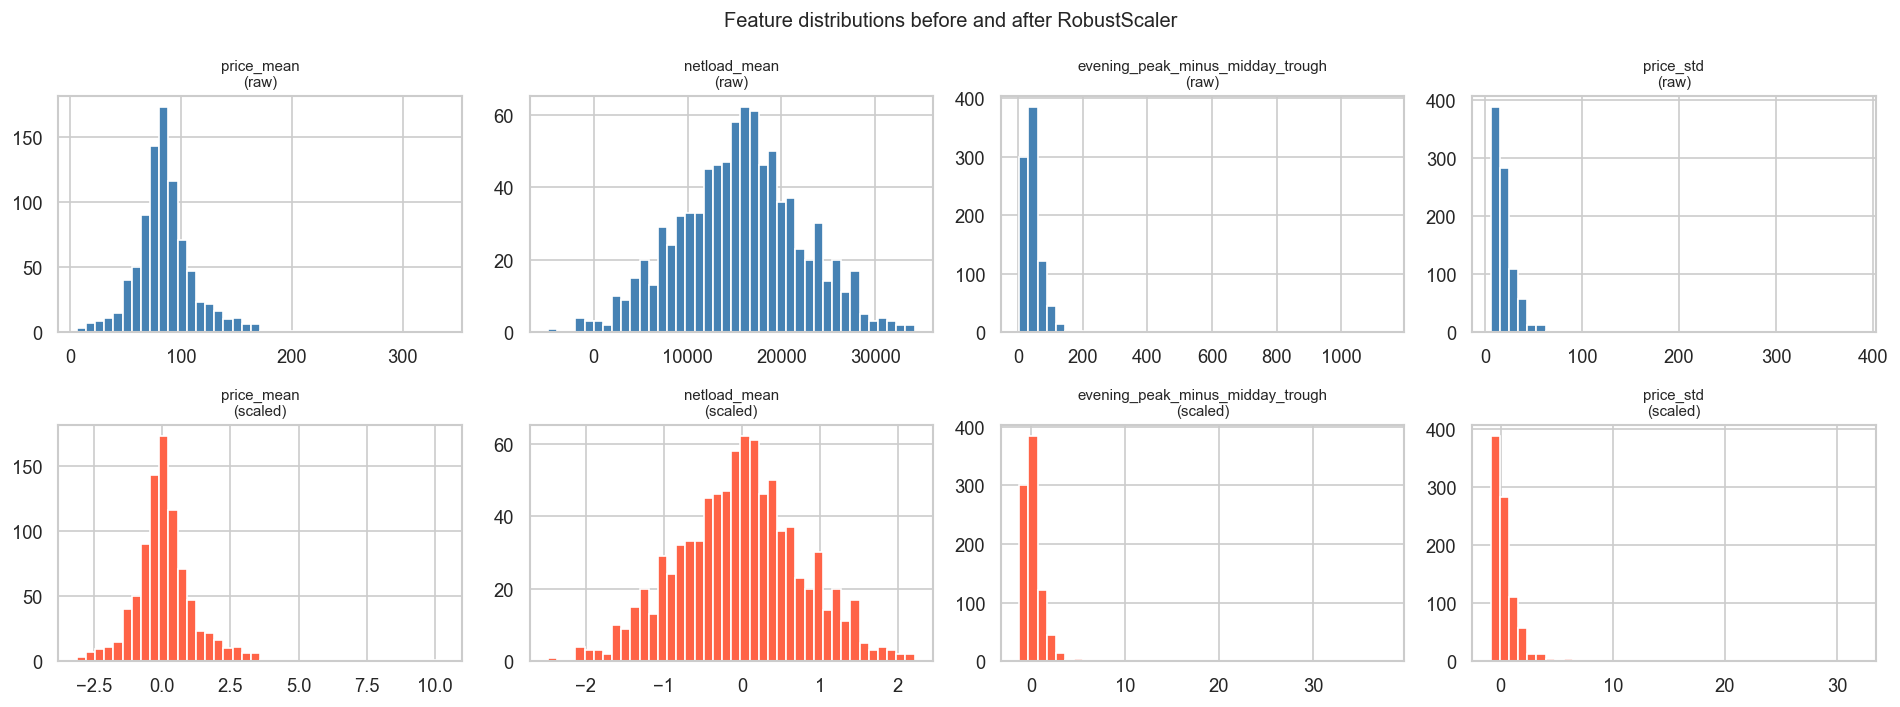

In [11]:
X_scaled, scaler, feature_cols = scale_features(daily_df)
print(f'Scaled matrix shape: {X_scaled.shape}')
print(f'Features used: {len(feature_cols)}')

# Show distribution before/after for selected summary features
sel_features = ['price_mean', 'netload_mean', 'evening_peak_minus_midday_trough', 'price_std']
sel_idx = [feature_cols.index(f) for f in sel_features if f in feature_cols]

fig, axes = plt.subplots(2, len(sel_idx), figsize=(4*len(sel_idx), 6))
for i, (feat, idx) in enumerate(zip(sel_features, sel_idx)):
    raw_vals = daily_df[feat].dropna()
    scaled_vals = X_scaled[:, idx]
    axes[0, i].hist(raw_vals, bins=40, color='steelblue', edgecolor='white')
    axes[0, i].set_title(f'{feat}\n(raw)', fontsize=9)
    axes[1, i].hist(scaled_vals, bins=40, color='tomato', edgecolor='white')
    axes[1, i].set_title(f'{feat}\n(scaled)', fontsize=9)
plt.suptitle('Feature distributions before and after RobustScaler', fontsize=12)
plt.tight_layout()
plt.show()

## 7. KMeans Results (k = 3, 4, 5, 6)

In [47]:
km_results = fit_kmeans(X_scaled, k_values=[2, 3, 4, 5, 6], n_init=20, seeds=[42, 123, 456])

# Aggregate metrics across seeds (take the best-inertia run per k)
km_summary = []
for k in [2, 3, 4, 5, 6]:
    best = min(
        [(seed, km_results[(k, seed)]) for seed in [42, 123, 456]],
        key=lambda x: x[1]['inertia']
    )
    seed, res = best
    metrics = evaluate_clusters(X_scaled, res['labels'])
    km_summary.append({
        'k': k, 'best_seed': seed, 'inertia': res['inertia'],
        'silhouette': metrics['silhouette'],
        'davies_bouldin': metrics['davies_bouldin'],
        'calinski_harabasz': metrics['calinski_harabasz'],
        'cluster_sizes': metrics['cluster_sizes'],
    })

km_df = pd.DataFrame(km_summary).set_index('k')
print('KMeans results (best seed per k):')
km_df[['inertia', 'silhouette', 'davies_bouldin', 'calinski_harabasz']].round(3)

INFO: Silhouette=0.203  DB=1.806  CH=217.0
INFO: Silhouette=0.205  DB=1.225  CH=183.1
INFO: Silhouette=0.169  DB=1.477  CH=165.7
INFO: Silhouette=0.127  DB=1.641  CH=149.4
INFO: Silhouette=0.123  DB=1.718  CH=137.3


KMeans results (best seed per k):


,inertia,silhouette,davies_bouldin,calinski_harabasz
k,,,,
2,46083.096,0.203,1.806,217.024
3,40513.563,0.205,1.225,183.089
4,36620.239,0.169,1.477,165.677
5,34089.551,0.127,1.641,149.438
6,32124.737,0.123,1.718,137.322


## 8. KMeans Model Selection

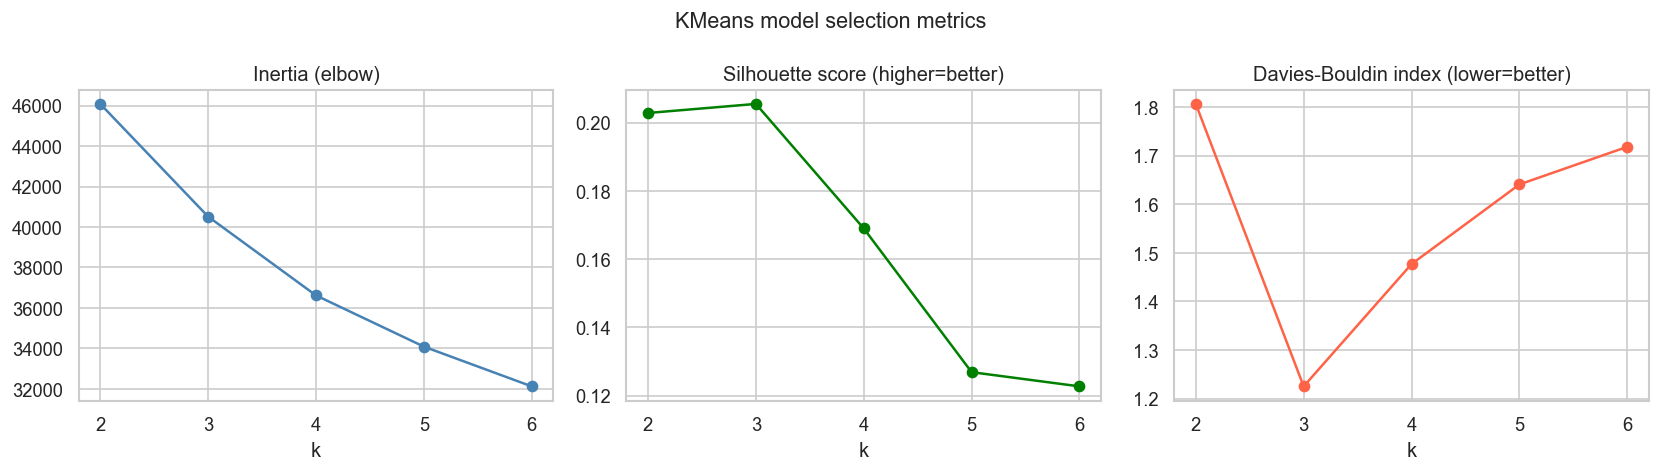

In [49]:
# Elbow plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
ks = [2, 3, 4, 5, 6]
axes[0].plot(ks, km_df['inertia'], 'o-', color='steelblue')
axes[0].set_title('Inertia (elbow)')
axes[0].set_xlabel('k')

axes[1].plot(ks, km_df['silhouette'], 'o-', color='green')
axes[1].set_title('Silhouette score (higher=better)')
axes[1].set_xlabel('k')

axes[2].plot(ks, km_df['davies_bouldin'], 'o-', color='tomato')
axes[2].set_title('Davies-Bouldin index (lower=better)')
axes[2].set_xlabel('k')

plt.suptitle('KMeans model selection metrics', fontsize=13)
plt.tight_layout()
plt.show()

## 9. GMM Results (k = 3, 4, 5, 6)

In [50]:
gmm_results = fit_gmm(X_scaled, k_values=[2,3, 4, 5, 6], seeds=[42, 123, 456])

# Aggregate by k — take minimum BIC run
gmm_summary = []
for k in [2, 3, 4, 5, 6]:
    best = min(
        [(seed, gmm_results[(k, seed)]) for seed in [42, 123, 456]],
        key=lambda x: x[1]['bic']
    )
    seed, res = best
    metrics = evaluate_clusters(X_scaled, res['labels'])
    gmm_summary.append({
        'k': k, 'best_seed': seed,
        'bic': res['bic'], 'aic': res['aic'],
        'silhouette': metrics['silhouette'],
        'davies_bouldin': metrics['davies_bouldin'],
        'calinski_harabasz': metrics['calinski_harabasz'],
    })

gmm_df = pd.DataFrame(gmm_summary).set_index('k')
print('GMM results (best seed per k):')
gmm_df[['bic', 'aic', 'silhouette', 'davies_bouldin', 'calinski_harabasz']].round(2)

INFO: Silhouette=0.076  DB=3.555  CH=42.8
INFO: Silhouette=0.085  DB=2.678  CH=104.5
INFO: Silhouette=0.158  DB=1.842  CH=132.0
INFO: Silhouette=0.120  DB=2.072  CH=107.9
INFO: Silhouette=0.102  DB=2.221  CH=98.9


GMM results (best seed per k):


,bic,aic,silhouette,davies_bouldin,calinski_harabasz
k,,,,,
2,-4582.82,-64971.66,0.08,3.56,42.83
3,31658.20,-58927.45,0.09,2.68,104.51
4,46685.19,-74097.27,0.16,1.84,132.01
5,74637.23,-76342.04,0.12,2.07,107.94
6,93386.93,-87789.15,0.10,2.22,98.86


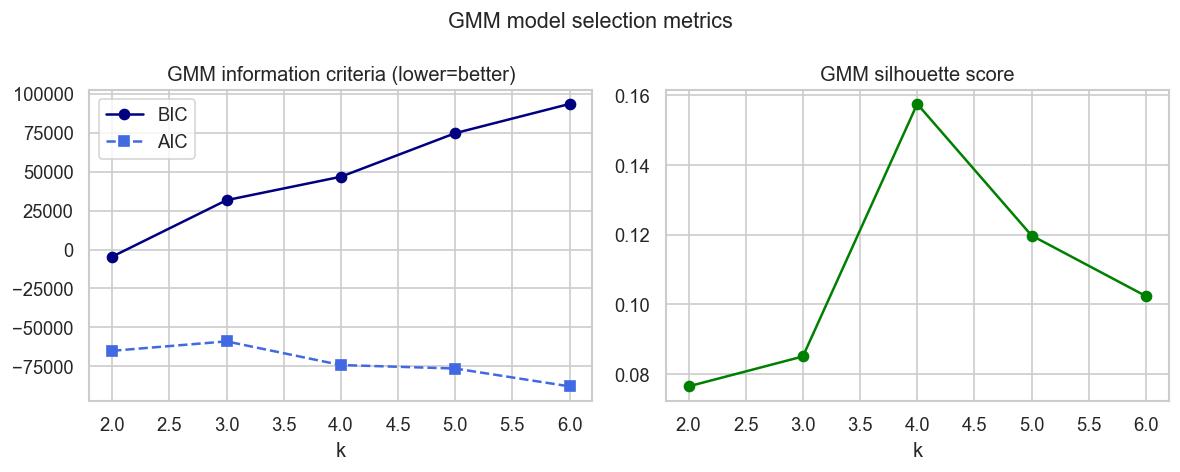

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(ks, gmm_df['bic'], 'o-', label='BIC', color='navy')
axes[0].plot(ks, gmm_df['aic'], 's--', label='AIC', color='royalblue')
axes[0].set_title('GMM information criteria (lower=better)')
axes[0].set_xlabel('k')
axes[0].legend()

axes[1].plot(ks, gmm_df['silhouette'], 'o-', color='green')
axes[1].set_title('GMM silhouette score')
axes[1].set_xlabel('k')

plt.suptitle('GMM model selection metrics', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Method Comparison Table

In [16]:
comparison_rows = []
for k in [3, 4, 5, 6]:
    comparison_rows.append({
        'method': 'KMeans', 'k': k,
        'silhouette': km_df.loc[k, 'silhouette'],
        'davies_bouldin': km_df.loc[k, 'davies_bouldin'],
        'calinski_harabasz': km_df.loc[k, 'calinski_harabasz'],
    })
    comparison_rows.append({
        'method': 'GMM', 'k': k,
        'silhouette': gmm_df.loc[k, 'silhouette'],
        'davies_bouldin': gmm_df.loc[k, 'davies_bouldin'],
        'calinski_harabasz': gmm_df.loc[k, 'calinski_harabasz'],
    })

comparison_df = pd.DataFrame(comparison_rows).set_index(['method', 'k'])
print('Method comparison:')
comparison_df.round(3)

Method comparison:


,,silhouette,davies_bouldin,calinski_harabasz
method,k,,,
KMeans,3,0.205,1.225,183.089
GMM,3,0.085,2.678,104.512
KMeans,4,0.169,1.477,165.677
GMM,4,0.158,1.842,132.007
KMeans,5,0.127,1.641,149.438
GMM,5,0.120,2.072,107.939
KMeans,6,0.123,1.718,137.322
GMM,6,0.102,2.221,98.865


## 11. Economic Interpretation

Using the preferred k=4 KMeans solution for interpretation.

In [56]:
# Select preferred solution
PREFERRED_K = 4
PREFERRED_METHOD = 'kmeans'

# Use best-seed (lowest inertia) run
best_km_seed = km_df.loc[PREFERRED_K, 'best_seed']
preferred_labels = km_results[(PREFERRED_K, best_km_seed)]['labels']
preferred_model = km_results[(PREFERRED_K, best_km_seed)]['model']
print(f'Using KMeans k={PREFERRED_K}, seed={best_km_seed}')
# preferred_labels = gmm_results[(PREFERRED_K, gmm_df.loc[PREFERRED_K, 'best_seed'])]['labels']
# preferred_model = gmm_results[(PREFERRED_K, gmm_df.loc[PREFERRED_K, 'best_seed'])]['model']
# print(f'Using GMM k={PREFERRED_K}, seed={gmm_df.loc[PREFERRED_K, "best_seed"]}')
print('Cluster sizes:')
unique, counts = np.unique(preferred_labels, return_counts=True)
for c, n in zip(unique, counts):
    print(f'  Cluster {c}: {n} days ({100*n/len(preferred_labels):.1f}%)')

Using KMeans k=4, seed=42
Cluster sizes:
  Cluster 0: 171 days (19.6%)
  Cluster 1: 362 days (41.5%)
  Cluster 2: 339 days (38.8%)
  Cluster 3: 1 days (0.1%)


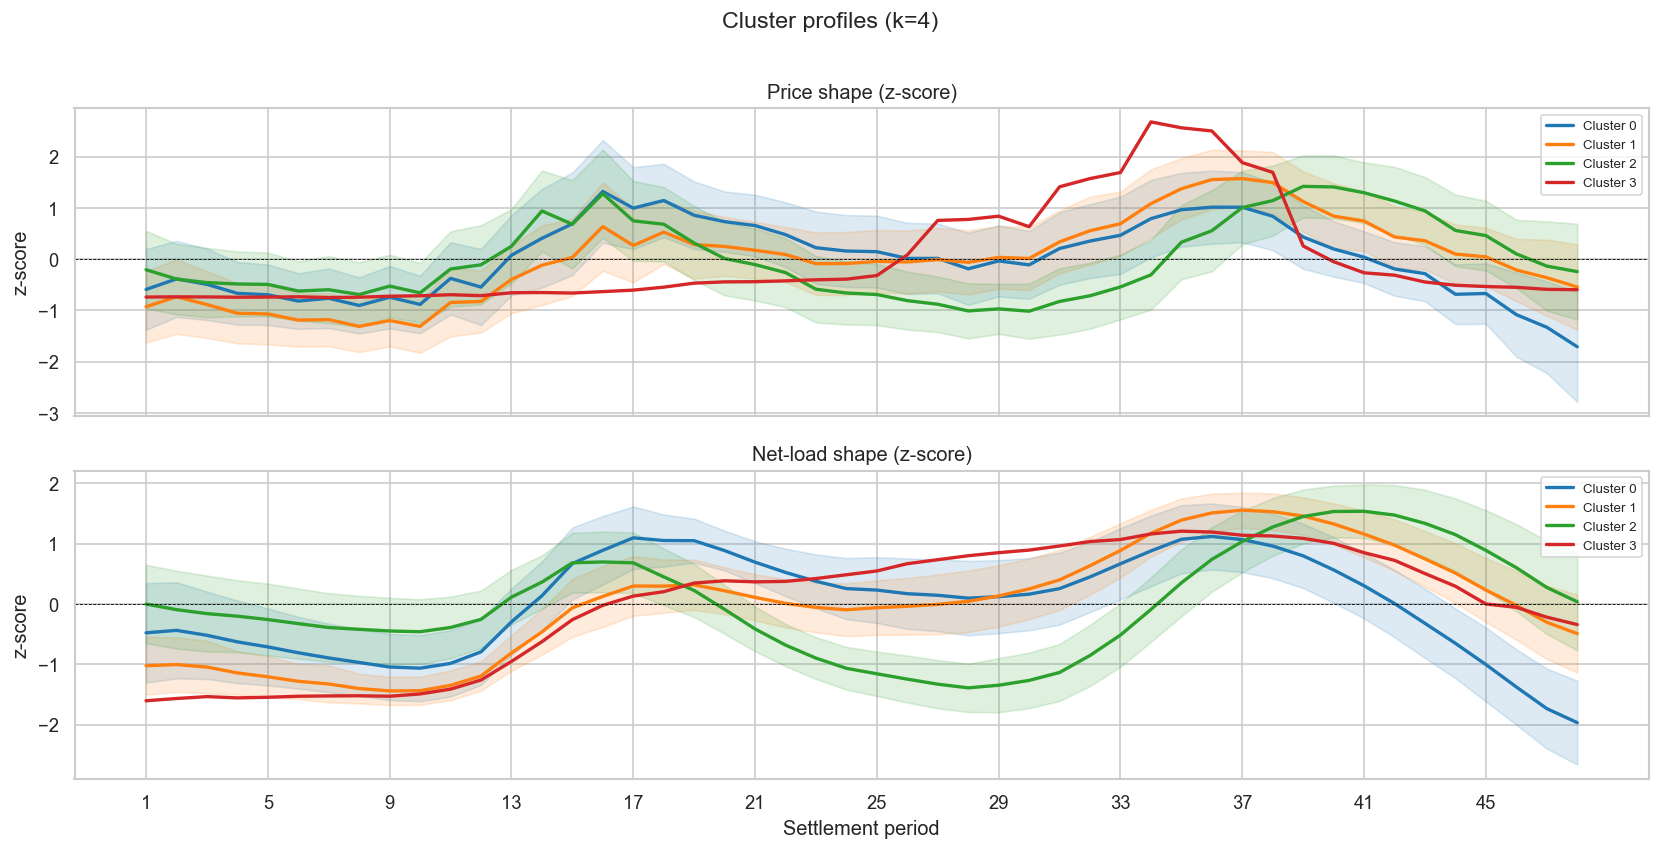

In [57]:
fig = plot_cluster_profiles(daily_df, preferred_labels, PREFERRED_K)
plt.show()

INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/Users/haowu/Projects/BESS/src/clustering/evaluation.py:157: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="cluster", y=col, ax=axes[i], palette="tab10")
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/Users/haowu/Projects/BESS/src/clustering/evaluation.py:157: FutureWarning: 

Passing `palette` 

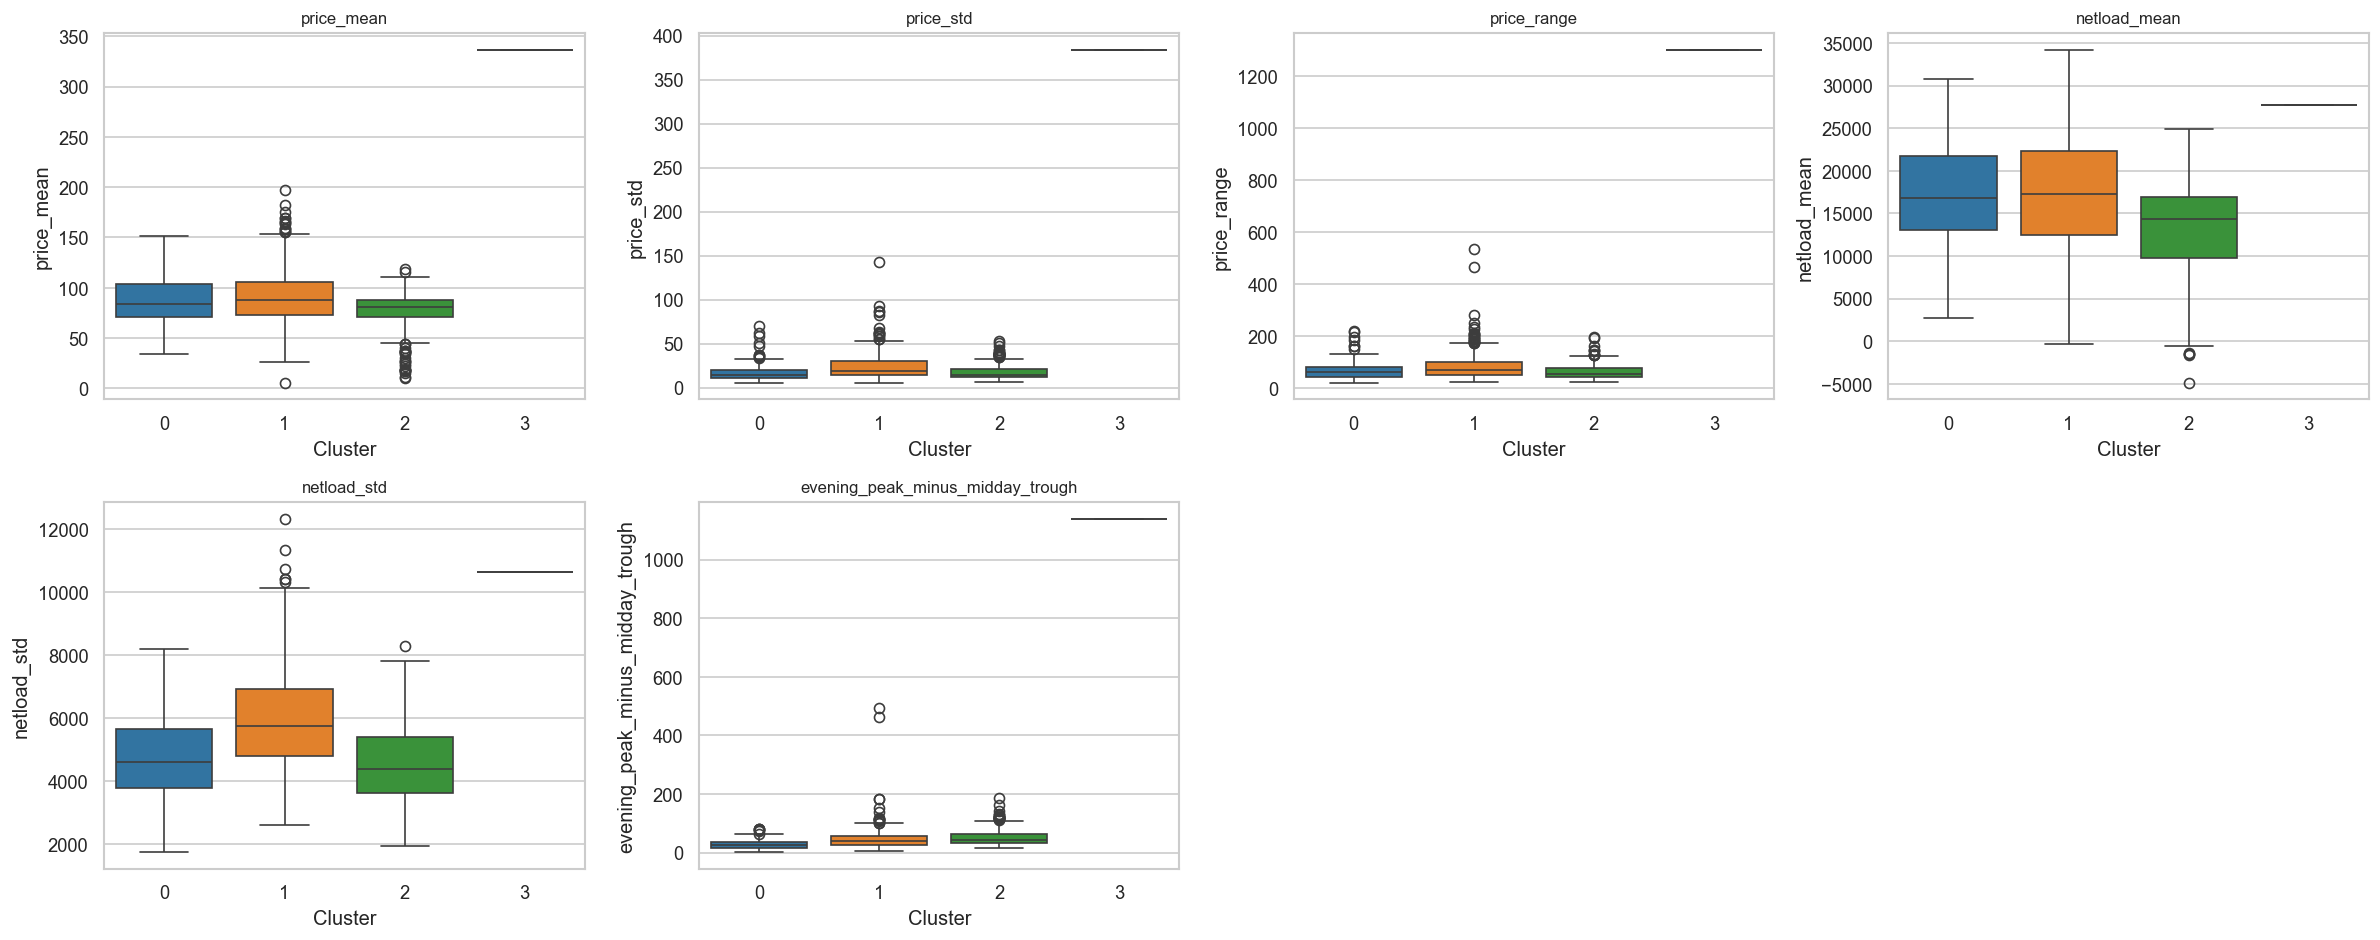

In [19]:
fig = plot_summary_distributions(daily_df, preferred_labels)
plt.show()

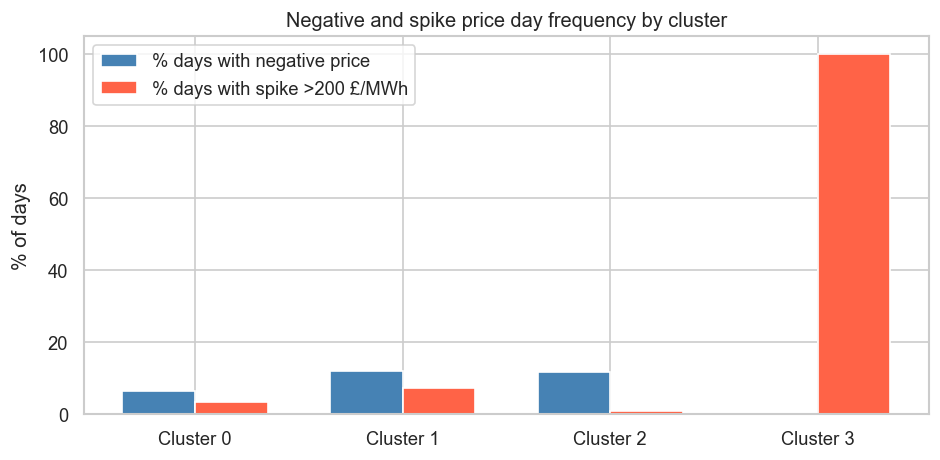

In [20]:
fig = plot_negative_and_spike_days(daily_df, preferred_labels)
plt.show()

## 12. Seasonality Analysis

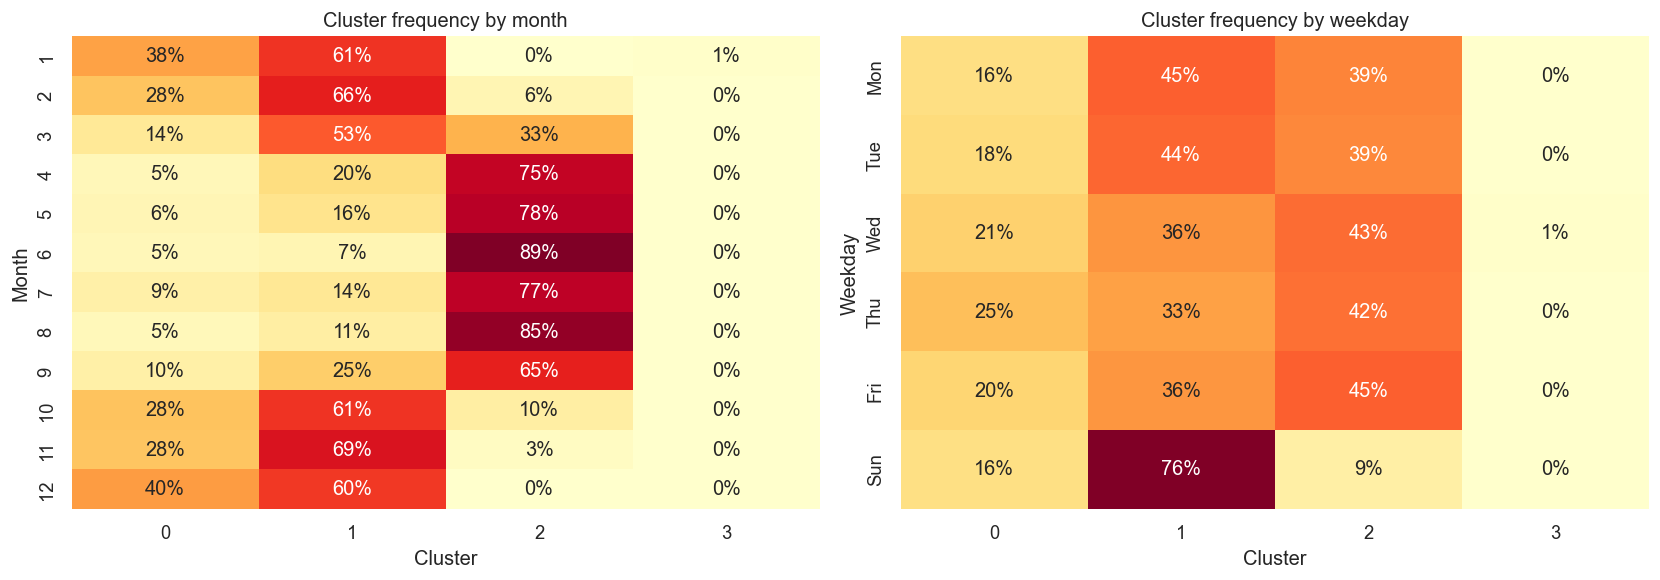

In [21]:
fig = plot_seasonality(daily_df, preferred_labels)
plt.show()

## 13. Stability Analysis

Bootstrap ARI distribution: repeatedly fit k=4 KMeans on 80% subsamples and
measure pairwise agreement. Mean ARI > 0.7 indicates a robust solution.

INFO: Stability mean ARI = 0.766 ± 0.183


Stability mean ARI = 0.766 ± 0.183


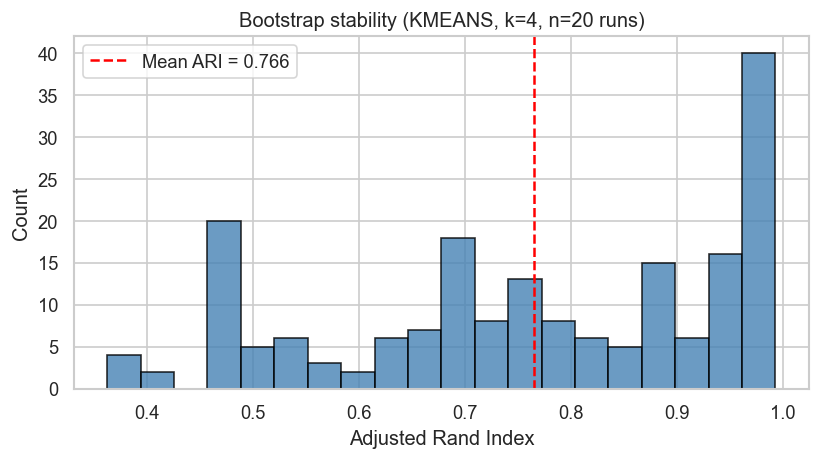

In [22]:
stability = stability_analysis(X_scaled, method='kmeans', k=PREFERRED_K, n_bootstrap=20, sample_frac=0.8)
print(f"Stability mean ARI = {stability['mean_ari']:.3f} ± {stability['std_ari']:.3f}")
plt.show()

After z-scoring the daily shape, the main source of variation is seasonal shape change, not discrete market-state clustering.

Clustering results suggests with the current features and normalization, the historical days do not separate into clearly distinct day types.

This clustering result does not currently justify a regime-conditioning layer for marginal quantile forecasting.

Redesigning regimes around price level, spread, and scarcity/tail behavior may help. But for now, I'll proceeed without regimes.

